In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ====== User Configurable ======
harmless_file = "/work/jcaspary/refusal_direction_image_load/pipeline/runs/6f6d72be3c7a8541d2942691c46fbd075c147352/harmful_complete_harmless_mmbench/0.1_0/n_train_harmful_100/all_activations/all_activations_harmless.pt"
harmful_file  = "/work/jcaspary/refusal_direction_image_load/pipeline/runs/6f6d72be3c7a8541d2942691c46fbd075c147352/harmful_complete_harmless_mmbench/0.1_0/n_train_harmful_100/all_activations/all_activations_harmful.pt"
selected_layer = 14     # e.g. 5 or None
selected_position = 0   # e.g. 0, -1 or None
# ===============================

# Load activation caches
activation_cache_harmless = torch.load(harmless_file)
activation_cache_harmful = torch.load(harmful_file)

print("Example shape from Layer 0 (harmless):", activation_cache_harmless[0][0].shape)

# Flatten utility
def flatten_activations(layer_activations, position_idx=None):
    """
    If position_idx is None: return (N * P, D)
    If position_idx is set: return (N, D) for that position only
    """
    tensors = []
    for sample in layer_activations:
        if position_idx is None:
            tensors.append(sample)  # (P, D)
        else:
            tensors.append(sample[position_idx].unsqueeze(0))  # (1, D)
    return torch.cat(tensors, dim=0)

# === Average Activation Magnitude ===
if selected_layer is None:
    avg_harmless = []
    avg_harmful = []
    for layer in sorted(activation_cache_harmless.keys()):
        acts_harmless = flatten_activations(activation_cache_harmless[layer], selected_position)
        acts_harmful = flatten_activations(activation_cache_harmful[layer], selected_position)

        avg_harmless.append(acts_harmless.abs().mean().item())
        avg_harmful.append(acts_harmful.abs().mean().item())

    plt.plot(avg_harmless, label="Harmless", color="blue")
    plt.plot(avg_harmful, label="Harmful", color="red")
    plt.title("Avg Activation Magnitude per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Avg |Activation|")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    acts_harmless = flatten_activations(activation_cache_harmless[selected_layer], selected_position)
    acts_harmful = flatten_activations(activation_cache_harmful[selected_layer], selected_position)

    mean_harmless = acts_harmless.abs().mean().item()
    mean_harmful = acts_harmful.abs().mean().item()

    print(f"[Layer {selected_layer}, Position {selected_position}]")
    print(f"  Harmless Avg |Activation|: {mean_harmless:.4f}")
    print(f"  Harmful  Avg |Activation|: {mean_harmful:.4f}")

# === Activation Distribution Histogram ===
if selected_layer is not None:
    activations_harmless = flatten_activations(activation_cache_harmless[selected_layer], selected_position)
    activations_harmful  = flatten_activations(activation_cache_harmful[selected_layer], selected_position)

    activations_harmless = activations_harmless.flatten().to(torch.float32).numpy()
    activations_harmful  = activations_harmful.flatten().to(torch.float32).numpy()

    plt.hist(activations_harmless, bins=100, alpha=0.6, label="Harmless", color="blue", density=True)
    plt.hist(activations_harmful, bins=100, alpha=0.6, label="Harmful", color="red", density=True)
    title = f"Activation Distribution - Layer {selected_layer}"
    if selected_position is not None:
        title += f", Position {selected_position}"
    plt.title(title)
    plt.xlabel("Activation value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


Example shape from Layer 0 (harmless): torch.Size([4, 4096])


IndexError: index 4 is out of bounds for dimension 0 with size 4

# Harmless samples: 100
# Harmful  samples: 16


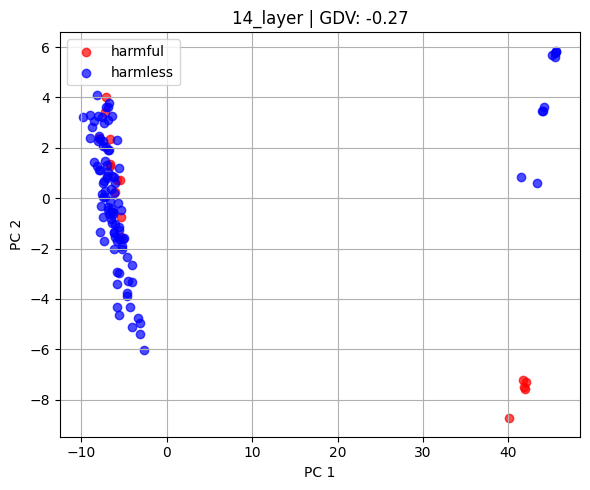

In [9]:
from sklearn.decomposition import PCA

# === PCA Visualization ===
if selected_layer is not None and selected_position is not None:
    # Get activations for selected layer and position
    activations_harmless = flatten_activations(activation_cache_harmless[selected_layer], selected_position)
    activations_harmful = flatten_activations(activation_cache_harmful[selected_layer], selected_position)

    print(f"# Harmless samples: {len(activations_harmless)}")
    print(f"# Harmful  samples: {len(activations_harmful)}")

    # Stack and label
    all_activations = torch.cat([activations_harmless, activations_harmful], dim=0).to(torch.float32)
    labels = np.array(["harmless"] * len(activations_harmless) + ["harmful"] * len(activations_harmful))

    # Perform PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(all_activations.numpy())

    # Separate points
    pcs_harmless = pcs[labels == "harmless"]
    pcs_harmful = pcs[labels == "harmful"]

    # Optional: compute GDV-like separation score
    centroid_diff = np.linalg.norm(pcs_harmless.mean(axis=0) - pcs_harmful.mean(axis=0))
    combined_std = np.mean([pcs_harmless.std(), pcs_harmful.std()])
    gdv_score = round(centroid_diff / combined_std - 1, 2)  # rough proxy for separation

    # Plot
    plt.figure(figsize=(6, 5))
    plt.scatter(pcs_harmful[:, 0], pcs_harmful[:, 1], color="red", alpha=0.7, label="harmful")
    plt.scatter(pcs_harmless[:, 0], pcs_harmless[:, 1], color="blue", alpha=0.7, label="harmless")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.title(f"{selected_layer}_layer | GDV: {gdv_score}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Searching for best separating layer/position using PCA + SVM...


/home/jcaspary/miniconda3/envs/refusal_dir2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/home/jcaspary/miniconda3/envs/refusal_dir2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/home/jcaspary/miniconda3/envs/refusal_dir2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/home/jcaspary/miniconda3/envs/refusal_dir2/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:789: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
/home/jcaspary/miniconda3/envs/refusal_dir2/lib/python3.10/site-packages

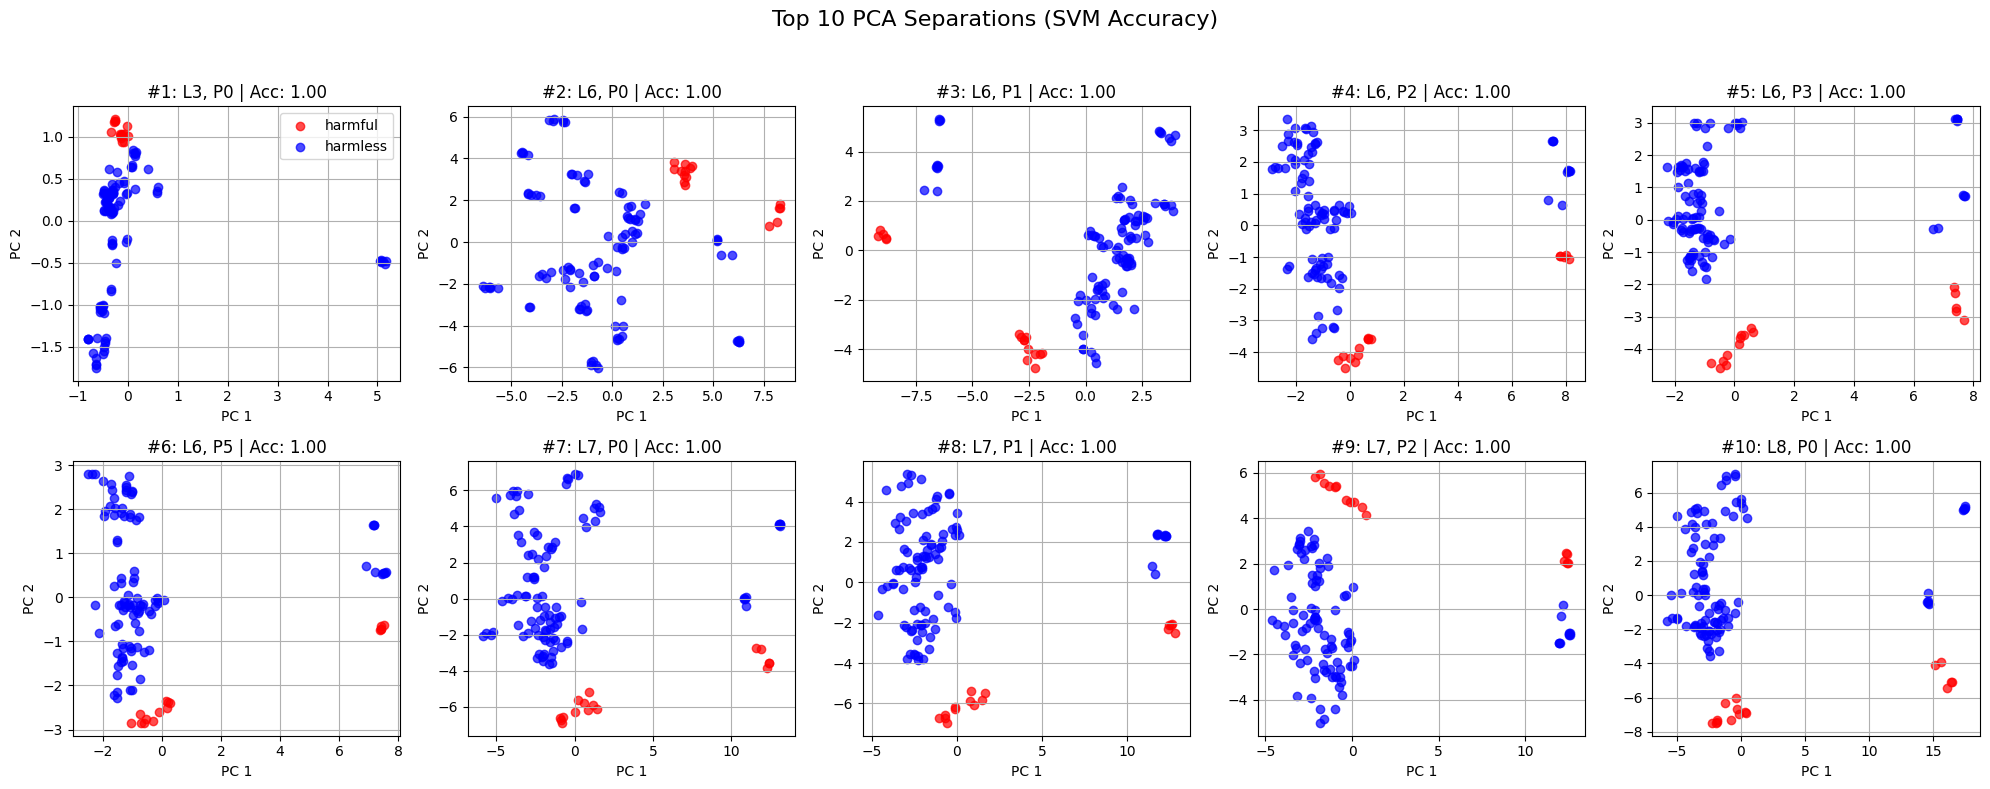


=== SVM Accuracy per Layer/Position ===
Layer  0: 0.86  0.86  0.86  0.86  0.86  0.86  
Layer  1: 0.86  0.86  0.86  0.86  0.86  0.86  
Layer  2: 0.84  0.86  0.86  0.86  0.86  0.86  
Layer  3: 1.00  0.86  0.86  0.86  0.86  0.86  
Layer  4: 0.86  0.86  0.90  0.91  0.86  0.86  
Layer  5: 0.86  0.97  0.95  0.94  0.86  0.84  
Layer  6: 1.00  1.00  1.00  1.00  0.84  1.00  
Layer  7: 1.00  1.00  1.00  0.99  0.84  0.99  
Layer  8: 1.00  1.00  1.00  0.99  0.84  0.88  
Layer  9: 1.00  1.00  0.99  0.95  0.85  0.89  
Layer 10: 1.00  1.00  0.97  0.86  0.86  0.86  
Layer 11: 0.99  0.99  1.00  0.86  0.86  0.86  
Layer 12: 0.85  1.00  1.00  0.86  0.86  0.86  
Layer 13: 0.84  0.99  0.98  0.86  0.86  0.91  
Layer 14: 0.86  0.99  0.91  0.87  0.86  0.91  
Layer 15: 0.86  0.97  0.91  0.89  0.91  0.91  
Layer 16: 0.86  0.98  0.91  0.89  0.91  0.91  
Layer 17: 0.86  0.98  0.89  0.85  0.91  0.95  
Layer 18: 0.86  0.98  0.93  0.86  0.91  0.91  
Layer 19: 0.86  0.97  0.95  0.86  0.86  0.97  
Layer 20: 0.86  0.9

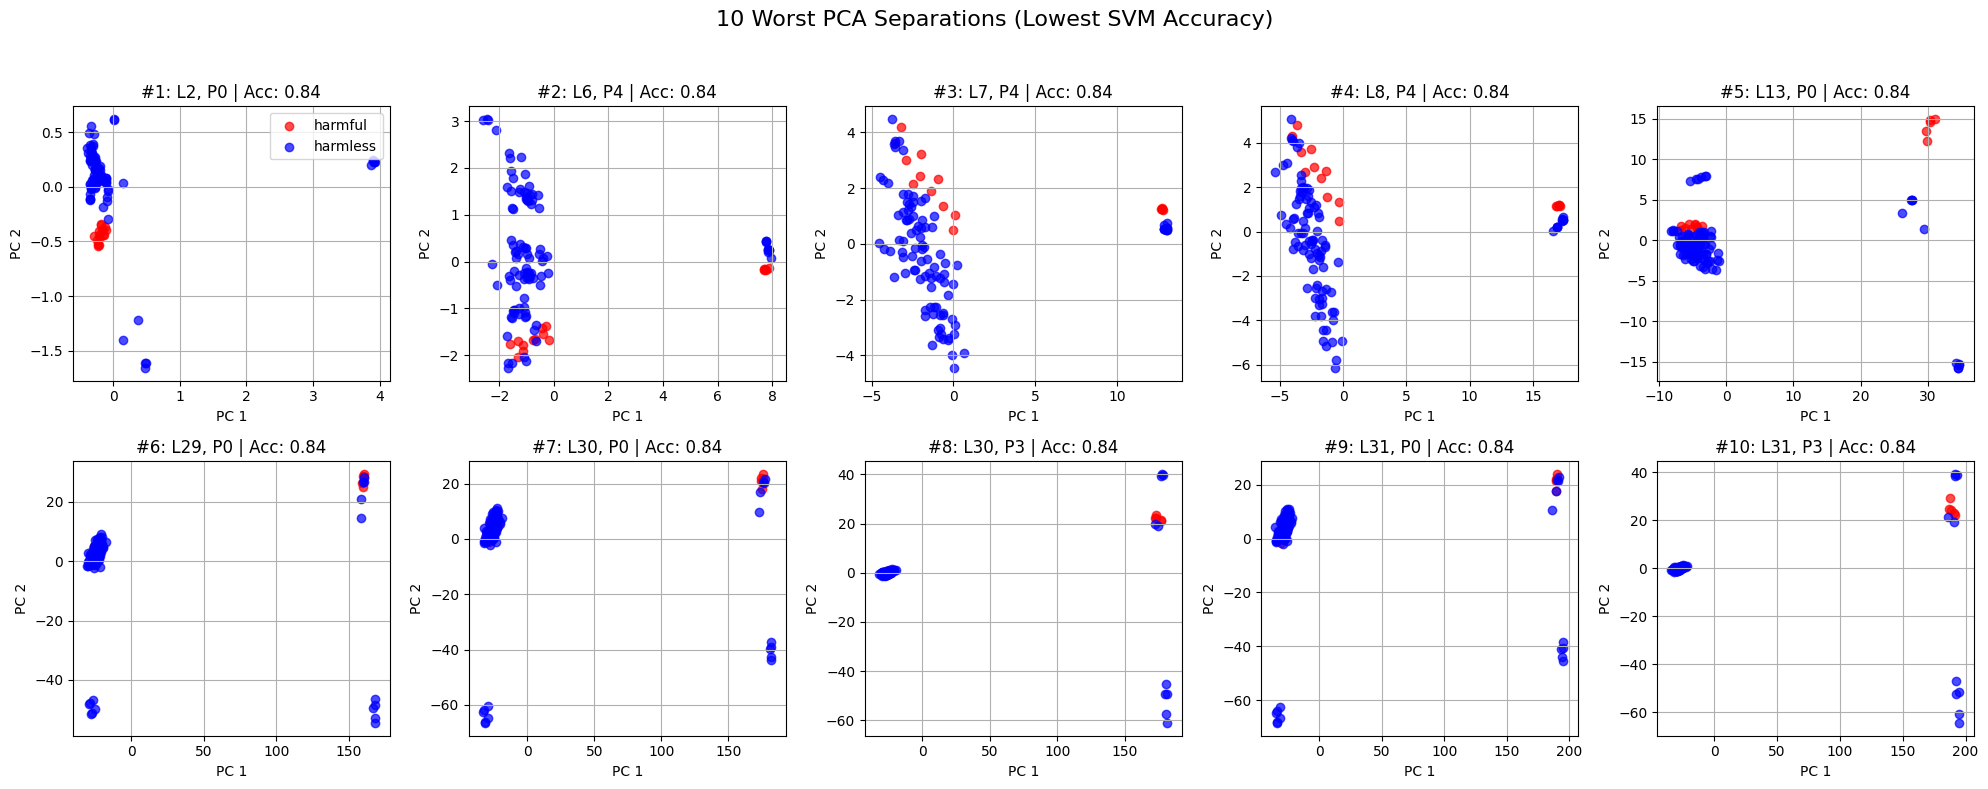

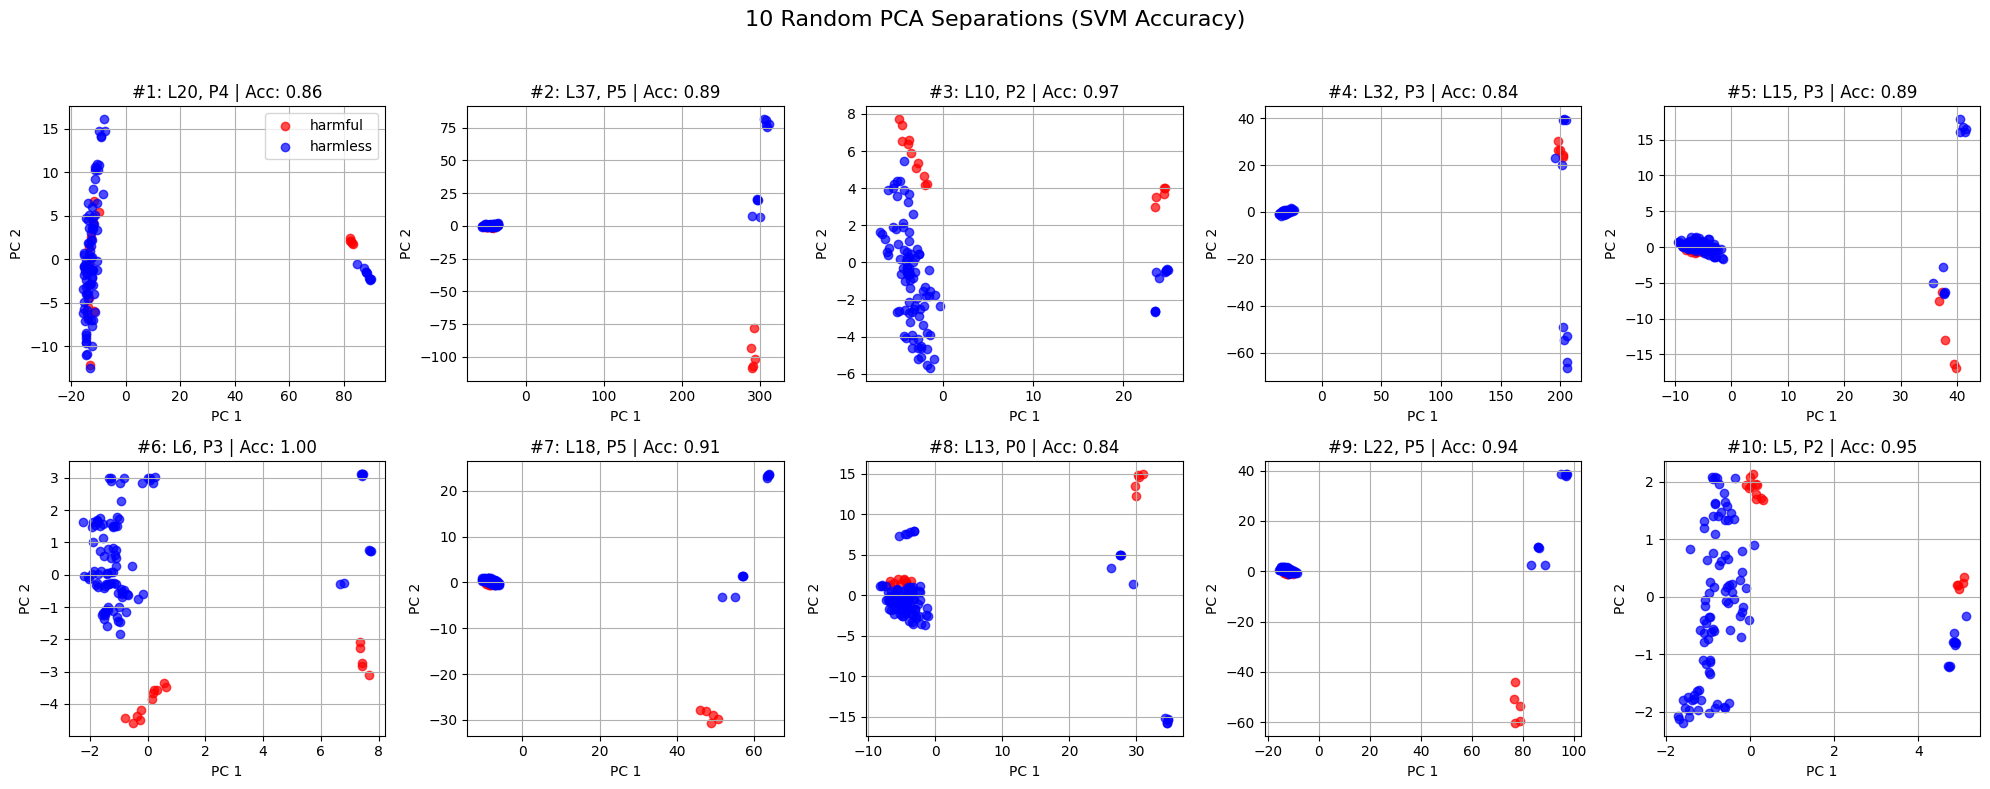

In [13]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import torch
from collections import defaultdict

# === Find Top 10 Separating Layer/Position Pairs ===

top_k = 10
all_results = []  # Store all for summary print
print("Searching for best separating layer/position using PCA + SVM...")

# Get number of positions from first layer
num_positions = activation_cache_harmless[0][0].shape[0]

for layer in activation_cache_harmless.keys():
    for position in range(num_positions):
        try:
            # Get activations
            acts_harmless = flatten_activations(activation_cache_harmless[layer], position)
            acts_harmful = flatten_activations(activation_cache_harmful[layer], position)

            if len(acts_harmless) == 0 or len(acts_harmful) == 0:
                continue

            # Stack and label
            all_acts = torch.cat([acts_harmless, acts_harmful], dim=0).to(torch.float32)
            labels = np.array([0] * len(acts_harmless) + [1] * len(acts_harmful))  # 0=harmless, 1=harmful

            # PCA
            pca = PCA(n_components=2)
            pcs = pca.fit_transform(all_acts.numpy())

            # SVM
            clf = SVC(kernel='linear')
            score = cross_val_score(clf, pcs, labels, cv=5).mean()

            # Save everything
            all_results.append((score, layer, position, pcs, labels))

        except Exception as e:
            print(f"Skipped layer {layer}, position {position} due to error: {e}")
            continue

# Sort top-k results
top_results = sorted(all_results, key=lambda x: x[0], reverse=True)[:top_k]

# === Plot Top Results (10) in 2 Rows ===
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

for ax, (rank, (score, layer, position, pcs, labels)) in zip(axs, enumerate(top_results, 1)):
    pcs_harmless = pcs[labels == 0]
    pcs_harmful = pcs[labels == 1]

    ax.scatter(pcs_harmful[:, 0], pcs_harmful[:, 1], color="red", alpha=0.7, label="harmful")
    ax.scatter(pcs_harmless[:, 0], pcs_harmless[:, 1], color="blue", alpha=0.7, label="harmless")
    ax.set_title(f"#{rank}: L{layer}, P{position} | Acc: {score:.2f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.grid(True)

# Add legend to first plot only
axs[0].legend()
plt.suptitle("Top 10 PCA Separations (SVM Accuracy)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === Print Full Table of Accuracies (Layer x Position) ===
# Build dict: {layer: {position: score}}
layer_pos_acc = defaultdict(dict)
for score, layer, position, *_ in all_results:
    layer_pos_acc[layer][position] = score

print("\n=== SVM Accuracy per Layer/Position ===")
for layer in sorted(layer_pos_acc.keys()):
    row = f"Layer {layer:2d}: "
    for pos in range(num_positions):
        acc = layer_pos_acc[layer].get(pos, None)
        if acc is not None:
            row += f"{acc:.2f}  "
        else:
            row += " --   "
    print(row)


import random

# === Plot 10 WORST Separating Results ===
worst_results = sorted(all_results, key=lambda x: x[0])[:10]

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

for ax, (rank, (score, layer, position, pcs, labels)) in zip(axs, enumerate(worst_results, 1)):
    pcs_harmless = pcs[labels == 0]
    pcs_harmful = pcs[labels == 1]

    ax.scatter(pcs_harmful[:, 0], pcs_harmful[:, 1], color="red", alpha=0.7, label="harmful")
    ax.scatter(pcs_harmless[:, 0], pcs_harmless[:, 1], color="blue", alpha=0.7, label="harmless")
    ax.set_title(f"#{rank}: L{layer}, P{position} | Acc: {score:.2f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.grid(True)

axs[0].legend()
plt.suptitle("10 Worst PCA Separations (Lowest SVM Accuracy)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# === Plot 10 RANDOM Layer-Position Combinations ===
random_results = random.sample(all_results, min(10, len(all_results)))

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()

for ax, (rank, (score, layer, position, pcs, labels)) in zip(axs, enumerate(random_results, 1)):
    pcs_harmless = pcs[labels == 0]
    pcs_harmful = pcs[labels == 1]

    ax.scatter(pcs_harmful[:, 0], pcs_harmful[:, 1], color="red", alpha=0.7, label="harmful")
    ax.scatter(pcs_harmless[:, 0], pcs_harmless[:, 1], color="blue", alpha=0.7, label="harmless")
    ax.set_title(f"#{rank}: L{layer}, P{position} | Acc: {score:.2f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.grid(True)

axs[0].legend()
plt.suptitle("10 Random PCA Separations (SVM Accuracy)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
